piecewise function:
x in [1, 20], y = 279.266
x in [20, 44], y = 894.402
x in [44, 58], y = 304.46
x in [58, 64], y = 356.871
sequence:
[279.26612855 279.26612855 279.26612855 279.26612855 279.26612855
 279.26612855 279.26612855 279.26612855 279.26612855 279.26612855
 279.26612855 279.26612855 279.26612855 279.26612855 279.26612855
 279.26612855 279.26612855 279.26612855 279.26612855 894.40157127
 894.40157127 894.40157127 894.40157127 894.40157127 894.40157127
 894.40157127 894.40157127 894.40157127 894.40157127 894.40157127
 894.40157127 894.40157127 894.40157127 894.40157127 894.40157127
 894.40157127 894.40157127 894.40157127 894.40157127 894.40157127
 894.40157127 894.40157127 894.40157127 304.46007725 304.46007725
 304.46007725 304.46007725 304.46007725 304.46007725 304.46007725
 304.46007725 304.46007725 304.46007725 304.46007725 304.46007725
 304.46007725 304.46007725 356.87131273 356.87131273 356.87131273
 356.87131273 356.87131273 356.87131273 356.87131273]


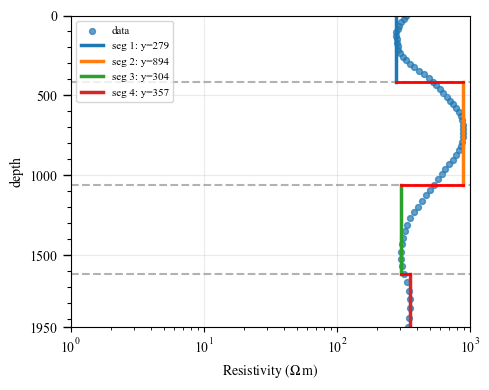

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "Arial Unicode MS"]
plt.rcParams["axes.unicode_minus"] = False



def find_extrema(y):
    y = np.asarray(y, dtype=float)
    if len(y) != 64:
        raise ValueError("y length must be 64")

    x = np.arange(1, 65, dtype=int)
    dy = np.diff(y)
    extrema = []

    i = 1
    while i < len(y) - 1:
        left = dy[i - 1]
        right = dy[i] if i < len(dy) else 0

        if left == 0 or right == 0:
            l = i - 1
            r = i
            while l >= 0 and dy[l] == 0:
                l -= 1
            while r < len(dy) and dy[r] == 0:
                r += 1
            left = dy[l] if l >= 0 else 0
            right = dy[r] if r < len(dy) else 0

        if left > 0 and right < 0:
            extrema.append((int(x[i]), float(y[i]), "max"))
        elif left < 0 and right > 0:
            extrema.append((int(x[i]), float(y[i]), "min"))
        i += 1

    return extrema


def build_piecewise_from_extrema(y, merge_y_threshold=50):
    x = np.arange(1, 65, dtype=int)
    extrema = find_extrema(y)

    if len(extrema) < 2:
        return [{"x_range": (1, 64), "c": float(np.mean(y))}]

    # 1) sort by x
    extrema = sorted(extrema, key=lambda e: e[0])

    # 2) merge adjacent extrema with very close y
    merged = []
    i = 0
    while i < len(extrema):
        x1, y1, _ = extrema[i]
        if i < len(extrema) - 1:
            x2, y2, _ = extrema[i + 1]
            if abs(y2 - y1) < merge_y_threshold:
                xm = int(round((x1 + x2) / 2.0))
                ym = (y1 + y2) / 2.0
                merged.append((xm, ym, "merge"))
                i += 2
                continue
        merged.append(extrema[i])
        i += 1

    extrema = merged
    if len(extrema) < 2:
        return [{"x_range": (1, 64), "c": float(np.mean(y))}]

    # 3) midpoints between adjacent extrema as boundaries
    x_ext = [e[0] for e in extrema]
    y_ext = {e[0]: e[1] for e in extrema}

    mids = []
    for i in range(len(x_ext) - 1):
        mid = (x_ext[i] + x_ext[i + 1]) / 2.0
        mids.append(int(round(mid)))

    boundaries = [1] + mids + [64]
    boundaries = sorted(set(boundaries))
    if boundaries[0] != 1:
        boundaries = [1] + boundaries
    if boundaries[-1] != 64:
        boundaries = boundaries + [64]

    # 4) choose c from nearest extrema to segment center
    segments = []
    for i in range(len(boundaries) - 1):
        x1, x2 = boundaries[i], boundaries[i + 1]
        midx = (x1 + x2) / 2.0
        nearest = min(x_ext, key=lambda xx: abs(xx - midx))
        c = y_ext[nearest]
        segments.append({"x_range": (x1, x2), "c": float(c)})

    return segments


def merge_adjacent_segments(segments, merge_y_threshold=30):
    if not segments:
        return segments

    merged = []
    i = 0
    while i < len(segments):
        cur = segments[i]
        x1, x2 = cur["x_range"]
        c = cur["c"]

        j = i + 1
        while j < len(segments):
            nxt = segments[j]
            if abs(nxt["c"] - c) < merge_y_threshold:
                x2 = nxt["x_range"][1]
                c = (c + nxt["c"]) / 2.0
                j += 1
            else:
                break

        merged.append({"x_range": (x1, x2), "c": float(c)})
        i = j

    return merged


def build_depth():
    deepth = np.zeros((64, 1))
    for i in range(63):
        deepth[i + 1, 0] = 20 + 10 ** (0.026026 * i) + deepth[i, 0]
    return deepth.reshape(1, -1).flatten()


def build_sequence_from_segments(segments, n=64):
    seq = np.empty(n, dtype=float)
    for i, seg in enumerate(segments):
        x1, x2 = seg["x_range"]
        start = x1 - 1
        end = (x2 - 1) if i < len(segments) - 1 else x2
        seq[start:end] = seg["c"]
    return seq


def plot_result(y, depth, segments):
    y = np.asarray(y, dtype=float).reshape(-1)
    depth = np.asarray(depth, dtype=float).reshape(-1)
    if len(y) != 64 or len(depth) != 64:
        raise ValueError("y and depth length must be 64")


    plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "mathtext.fontset": "stix",
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "axes.unicode_minus": False,
    })



    plt.figure(figsize=(5, 4))
    # swap axes: x = y, y = depth
    plt.scatter(y, depth, s=18, alpha=0.7, label="data", color="tab:blue")

    for idx, seg in enumerate(segments, 1):
        x1, x2 = seg["x_range"]
        c = float(seg["c"])
        y1 = depth[x1 - 1]
        y2 = depth[x2 - 1]
        plt.plot([c, c], [y1, y2], linewidth=2.5, label=f"seg {idx}: y={c:.3g}")

    # boundary depth lines + collect boundary depths
    boundary_depths = []
    for seg in segments[:-1]:
        boundary_idx = seg["x_range"][1]
        boundary_depth = depth[boundary_idx - 1]
        boundary_depths.append(boundary_depth)
        plt.axhline(y=boundary_depth, color="gray", linestyle="--", alpha=0.6)

    # horizontal red connections only
    if boundary_depths:
        c_vals = [float(seg["c"]) for seg in segments]
        for i, d in enumerate(boundary_depths):
            x_left = c_vals[i]
            x_right = c_vals[i + 1]
            plt.plot([x_left, x_right], [d, d], color="red", linewidth=2)

    plt.xlim(1, 1001)
    plt.ylim(0, 1950)

    ax = plt.gca()
    ax.set_yticks([0, 500, 1000, 1500, 1950])  # Major ticks
    ax.yaxis.set_minor_locator(MultipleLocator(100))  # Minor ticks
    ax.tick_params(axis="y", which="major", length=6, width=1)
    ax.tick_params(axis="y", which="minor", length=3, width=0.8)

    plt.xlabel(r"$\mathrm{Resistivity}\ (\Omega\,\mathrm{m})$")
    plt.xscale("log")
    plt.ylabel("depth")
    plt.gca().invert_yaxis()
    # plt.title("Piecewise Constant from Extrema (y vs depth)")
    plt.grid(alpha=0.25)
    plt.legend(fontsize=8)
    plt.tight_layout()

    # Save figures
    plt.savefig("F4.png", dpi=600, bbox_inches="tight")
    plt.savefig("F4.svg", bbox_inches="tight")

    plt.show()






if __name__ == "__main__":
    Y_data = np.load("Y_all.npy")
    y = Y_data[2050, 1, :]

    depth = build_depth()

    segs = build_piecewise_from_extrema(y)
    segs = merge_adjacent_segments(segs, merge_y_threshold=50)

    print("piecewise function:")
    for s in segs:
        print(f"x in [{s['x_range'][0]}, {s['x_range'][1]}], y = {s['c']:.6g}")
        
    seq = build_sequence_from_segments(segs, n=64)
    print("sequence:")
    print(seq)

    plot_result(y, depth, segs)  # Comment this out during batch calls if plotting is not needed
